# import

In [353]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

import my_module as my

***
# 0. Leitura e processamento inicial de dados

In [354]:
df = pd.read_csv('data/dados.csv', index_col='Data')
df.head()

,Último,Abertura,Máxima,Mínima,Vol.,Var%
Data,,,,,,
30.06.2025,138.855,136.865,139.103,136.430,"7,68M","1,45%"
27.06.2025,136.866,137.113,137.209,136.469,"6,24B","-0,18%"
26.06.2025,137.114,135.767,137.353,135.756,"8,02B","0,99%"
25.06.2025,135.767,137.163,137.163,135.565,"7,71B","-1,02%"
24.06.2025,137.165,136.552,138.156,136.254,"8,08B","0,45%"


In [355]:
col_dict = my.format_columns(df)
df.head()

,ultimo,abertura,maxima,minima,vol,var
Data,,,,,,
30.06.2025,138.855,136.865,139.103,136.430,"7,68M","1,45%"
27.06.2025,136.866,137.113,137.209,136.469,"6,24B","-0,18%"
26.06.2025,137.114,135.767,137.353,135.756,"8,02B","0,99%"
25.06.2025,135.767,137.163,137.163,135.565,"7,71B","-1,02%"
24.06.2025,137.165,136.552,138.156,136.254,"8,08B","0,45%"


In [356]:
df.dtypes

ultimo      float64
abertura    float64
maxima      float64
minima      float64
vol          object
var          object
dtype: object

## Tratamento e formatação de valores

In [357]:
# Formatacao e nomeacao do index
df.index = pd.to_datetime(df.index, dayfirst=True)
df.index = df.index.rename('data')
col_dict ['data'] = 'Data'
df.head()

,ultimo,abertura,maxima,minima,vol,var
data,,,,,,
2025-06-30,138.855,136.865,139.103,136.430,"7,68M","1,45%"
2025-06-27,136.866,137.113,137.209,136.469,"6,24B","-0,18%"
2025-06-26,137.114,135.767,137.353,135.756,"8,02B","0,99%"
2025-06-25,135.767,137.163,137.163,135.565,"7,71B","-1,02%"
2025-06-24,137.165,136.552,138.156,136.254,"8,08B","0,45%"


In [358]:
# Tornando 'var' em numero
df['var'] = df['var'].replace('%','',regex=True).replace(',','.',regex=True)
df['var'] = df['var'].astype(float)
df.head()

,ultimo,abertura,maxima,minima,vol,var
data,,,,,,
2025-06-30,138.855,136.865,139.103,136.430,"7,68M",1.45
2025-06-27,136.866,137.113,137.209,136.469,"6,24B",-0.18
2025-06-26,137.114,135.767,137.353,135.756,"8,02B",0.99
2025-06-25,135.767,137.163,137.163,135.565,"7,71B",-1.02
2025-06-24,137.165,136.552,138.156,136.254,"8,08B",0.45


In [359]:
# Ordenando nosso index
df = df.sort_index()
df.head()

,ultimo,abertura,maxima,minima,vol,var
data,,,,,,
2010-01-29,65.402,65.591,66.576,65.140,"1,82M",-0.28
2010-02-01,66.572,65.402,66.763,65.362,"1,49M",1.79
2010-02-02,67.163,66.589,67.321,66.539,"1,59M",0.89
2010-02-03,67.109,67.163,67.347,66.774,"1,76M",-0.08
2010-02-04,63.934,67.100,67.100,63.750,"2,26M",-4.73


In [360]:
# Retirando colunas irrelevantes
df = df.drop(['maxima','minima', 'abertura', 'vol'], axis=1)
df.head()

,ultimo,var
data,,
2010-01-29,65.402,-0.28
2010-02-01,66.572,1.79
2010-02-02,67.163,0.89
2010-02-03,67.109,-0.08
2010-02-04,63.934,-4.73


In [361]:
def make_alta(df : pd.DataFrame, from_column : str = 'var'):
    df['alta'] = False
    df.loc[df[from_column] > 0, 'alta'] = True
    return df

In [362]:
df = make_alta(df)
df

,ultimo,var,alta
data,,,
2010-01-29,65.402,-0.28,False
2010-02-01,66.572,1.79,True
2010-02-02,67.163,0.89,True
2010-02-03,67.109,-0.08,False
2010-02-04,63.934,-4.73,False
...,...,...,...
2025-06-24,137.165,0.45,True
2025-06-25,135.767,-1.02,False
2025-06-26,137.114,0.99,True


# 1. Análise inicial

In [363]:
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [364]:
sns.set_style('darkgrid')

In [365]:
studied = 'var'
target = 'alta'

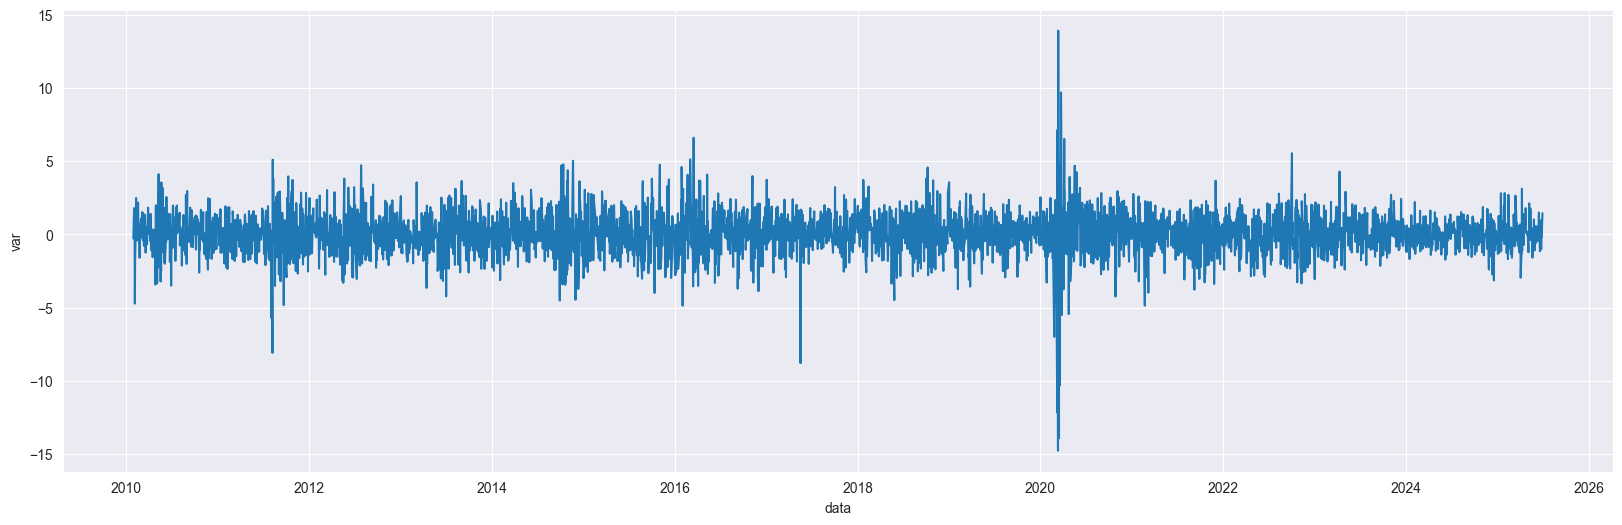

In [366]:
fig = plt.figure(figsize=(20,6))
sns.lineplot(
    df[studied]
);

## Dados originais

#### import

In [367]:
from statsmodels.tsa.seasonal import seasonal_decompose, MSTL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

### functions

In [368]:
def seasonality_search(df : pd.DataFrame, column : str, mask):
    results = []
    for p in range(2, 31):
        result = seasonal_decompose(
            df[column].loc[mask],
            model = 'additive',
            period = p
        )

        results.append((p, abs(result.resid.mean())))

    results.sort(key = lambda x: x[1])
    return results

## Var

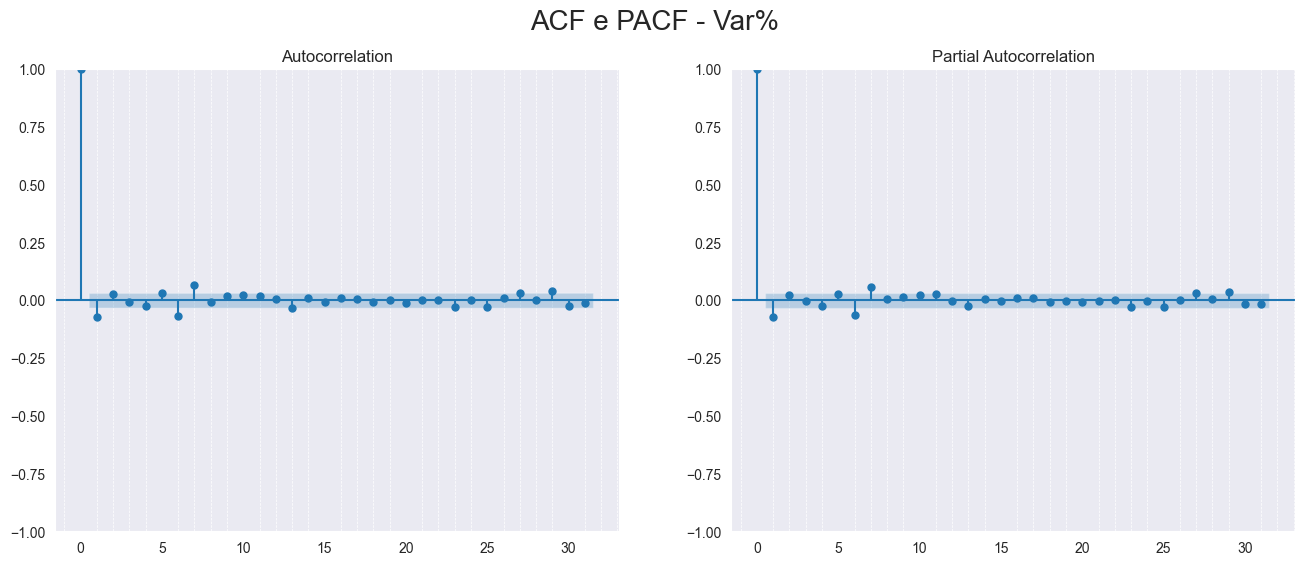

In [369]:
lags = 31

fig, axs = plt.subplots(
    nrows = 1,
    ncols = 2,
    figsize = (16, 6)
)

fig.suptitle(
    f'ACF e PACF - {col_dict[studied]}',
    fontsize = 20
)

ax = axs[0]
plot_acf(
    df[studied],
    ax = ax,
    lags = lags
)
ax.xaxis.set_minor_locator(ticker.MultipleLocator(1,1))
ax.set_axisbelow(True)
ax.grid(
    which = 'major'
)
ax.grid(
    which = 'minor',
    linestyle = '--',
    linewidth = 0.5
)

ax = axs[1]
plot_pacf(
    df[studied],
    ax = ax,
    lags = lags
)
ax.xaxis.set_minor_locator(ticker.MultipleLocator(1,1))
ax.set_axisbelow(True)
ax.grid(
    which = 'major'
)
ax.grid(
    which = 'minor',
    linestyle = '--',
    linewidth = 0.5
)

plt.show()


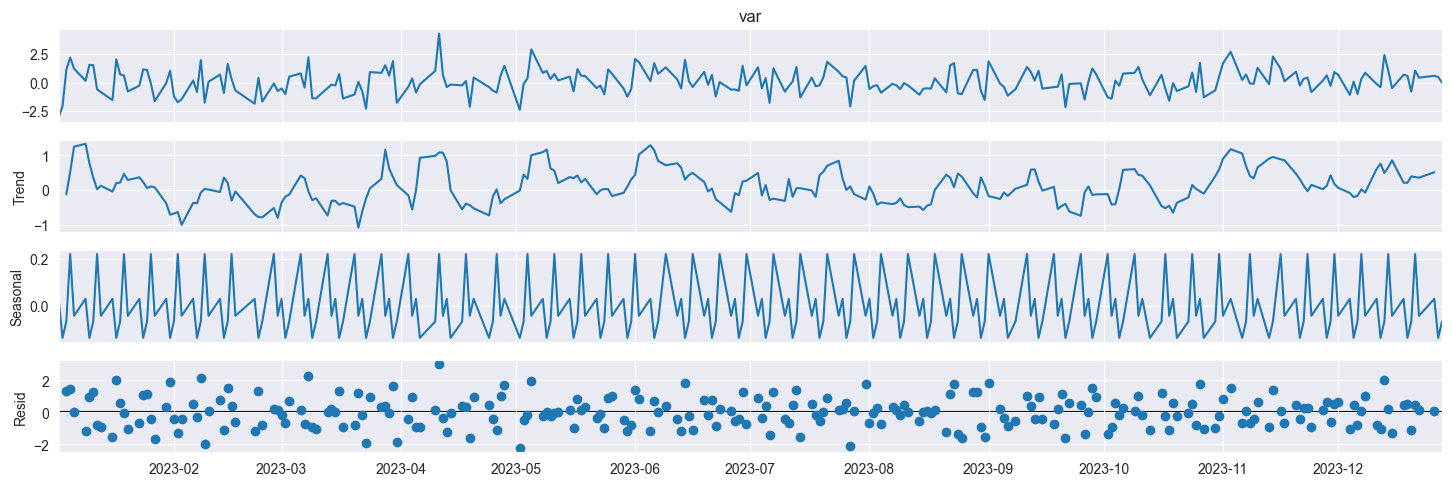

In [370]:
year = 2023
mask = ((df.index > f'{year-1}-12-31') & (df.index < f'{year+1}-01-01'))
fig = seasonal_decompose(
    df[studied].loc[mask],
    model = 'additive',
    period = 5
).plot();

fig.set_size_inches(16, 5)

In [371]:
results = seasonality_search(df, studied, mask)

results[:10]

[(26, np.float64(0.00017659023668641321)),
 (12, np.float64(0.00020413011695909317)),
 (13, np.float64(0.0005368697878819161)),
 (20, np.float64(0.0005551136363636108)),
 (8, np.float64(0.0006093749999999639)),
 (9, np.float64(0.0009982061833913518)),
 (2, np.float64(0.0015040650406504034)),
 (3, np.float64(0.0020054200542005524)),
 (19, np.float64(0.002006534555011016)),
 (21, np.float64(0.00221521335807048))]

0.5203675396231702 -0.0008544740522706817


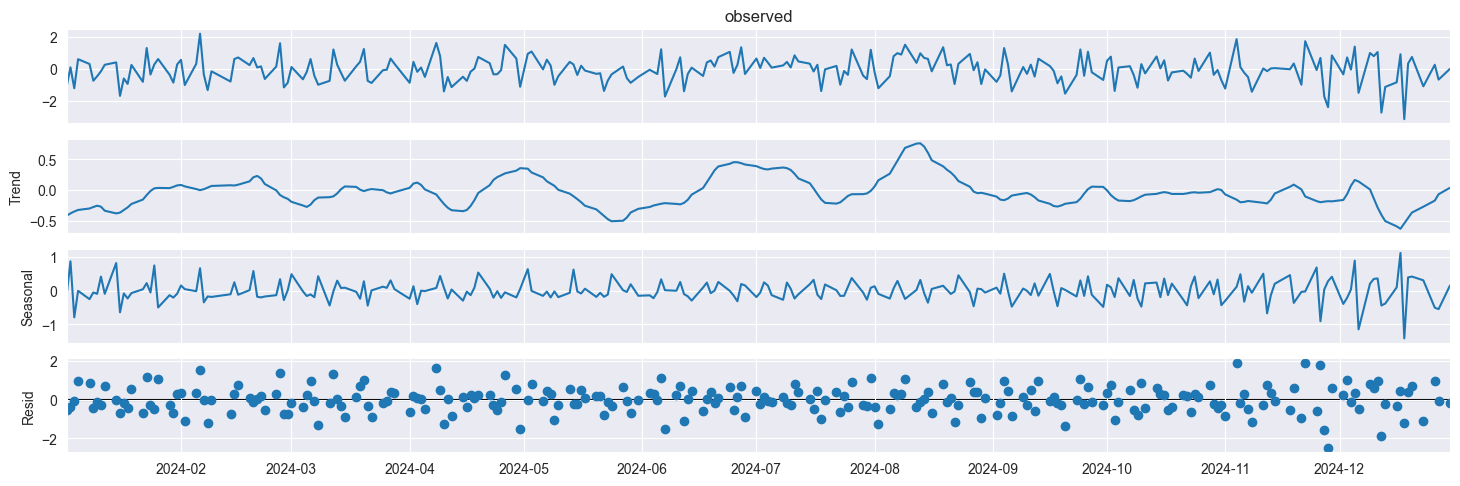

In [372]:
year = 2024
mask = ((df.index > f'{year-1}-12-31') & (df.index < f'{year+1}-01-01'))

mstl = MSTL(
    df[studied].loc[mask],
    periods = [8])
mstl_fit = mstl.fit()

fig = mstl_fit.plot()

fig.set_size_inches(16, 5)

print(mstl_fit.resid.abs().mean(), mstl_fit.resid.mean())

## Alta e baixa

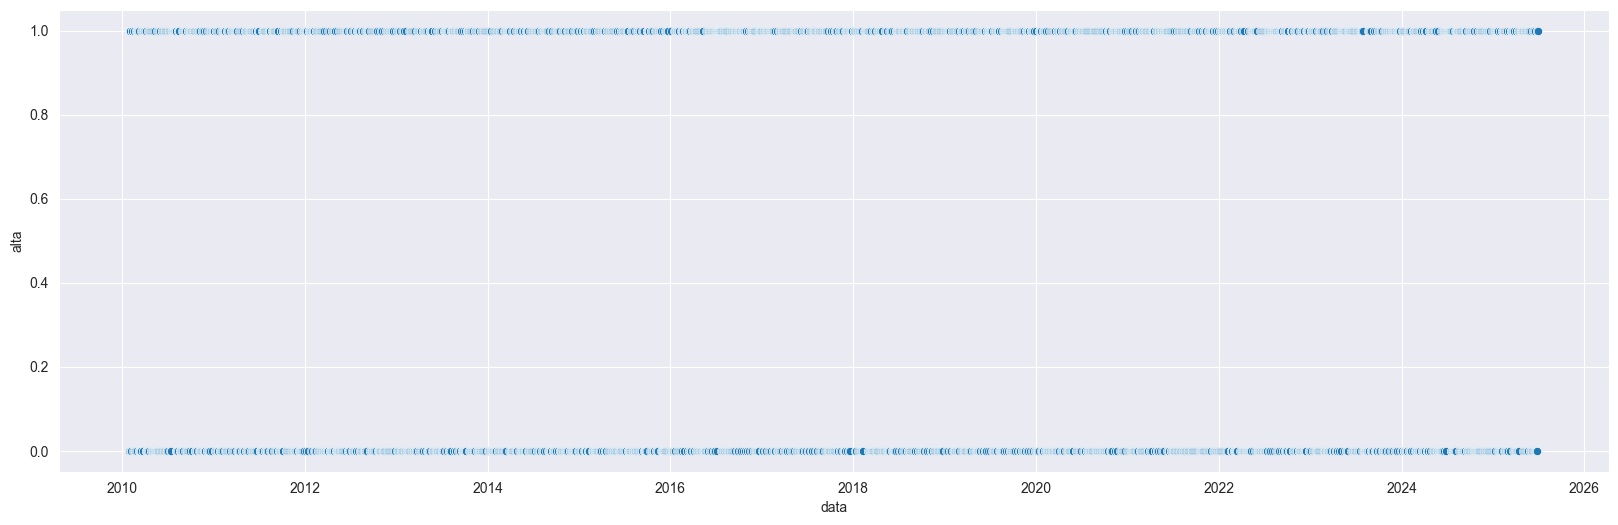

In [373]:
fig = plt.figure(figsize=(20,6))
sns.scatterplot(
    df[target]
);

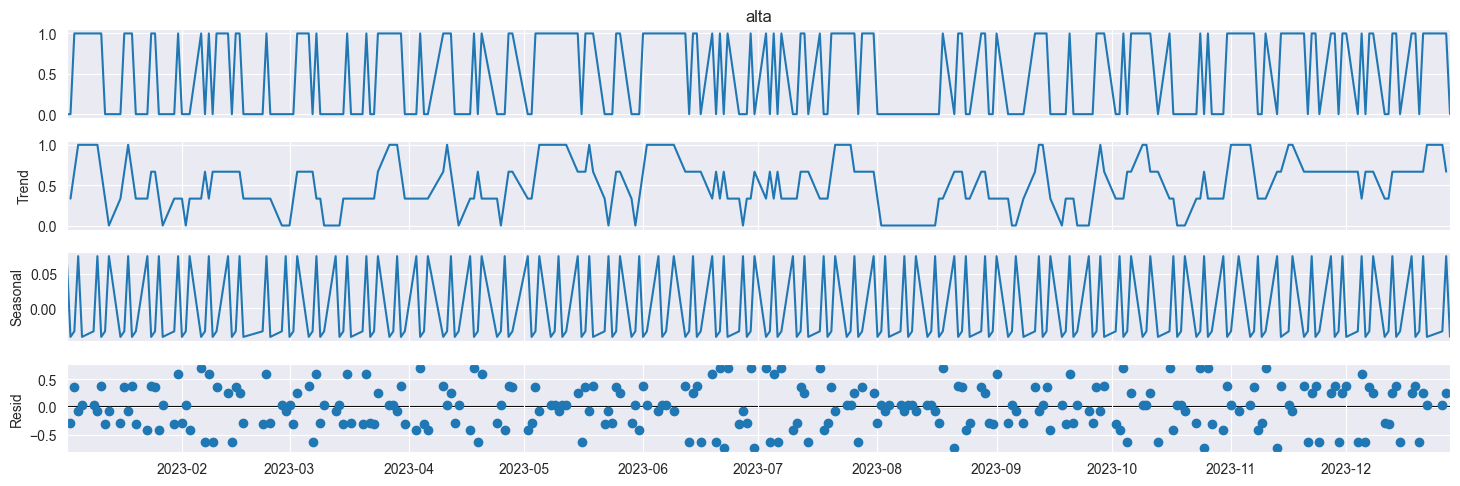

In [374]:
year = 2023
mask = ((df.index > f'{year-1}-12-31') & (df.index < f'{year+1}-01-01'))
fig = seasonal_decompose(
    df[target].loc[mask],
    model = 'additive',
    period = 3
).plot();

fig.set_size_inches(16, 5)

In [375]:
results = seasonality_search(df, target, mask)
results[:10]

[(8, np.float64(1.8503717077085942e-18)),
 (25, np.float64(0.00011111111111111688)),
 (9, np.float64(0.0002286236854138294)),
 (27, np.float64(0.0002667276329828249)),
 (2, np.float64(0.0010162601626016279)),
 (20, np.float64(0.0011363636363636897)),
 (13, np.float64(0.0012630194816429796)),
 (3, np.float64(0.001355013550135527)),
 (22, np.float64(0.0013711495116453547)),
 (6, np.float64(0.0016514227642276708))]

## Ultimo


In [376]:
studied = 'ultimo'

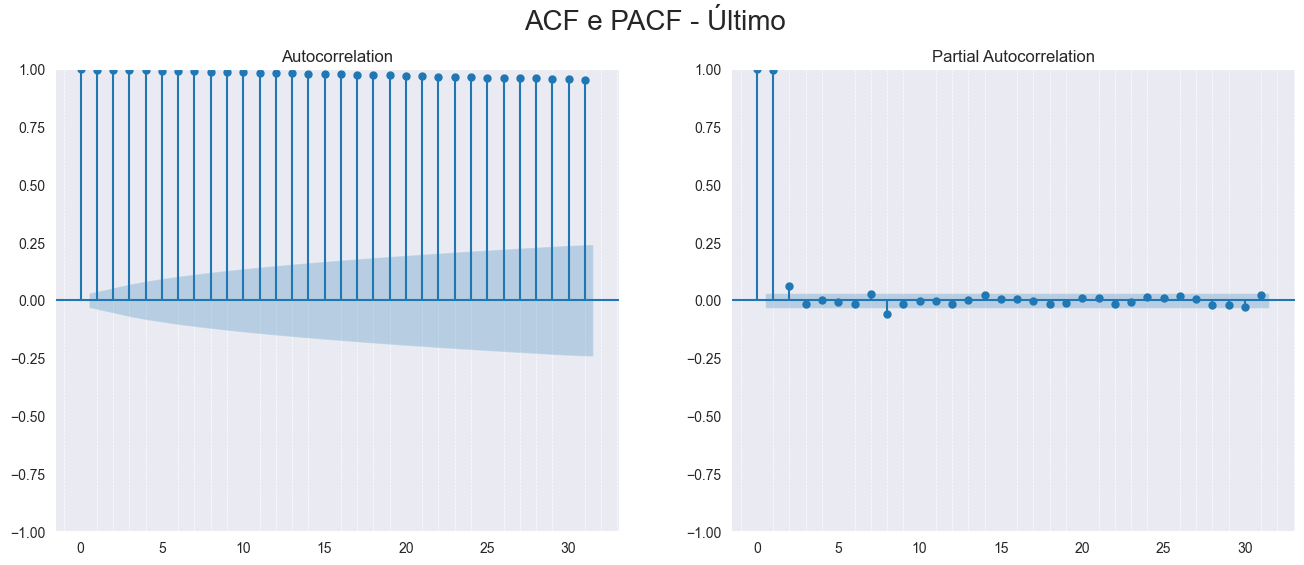

In [377]:
lags = 31

fig, axs = plt.subplots(
    nrows = 1,
    ncols = 2,
    figsize = (16, 6)
)

fig.suptitle(
    f'ACF e PACF - {col_dict[studied]}',
    fontsize = 20
)

ax = axs[0]
plot_acf(
    df[studied],
    ax = ax,
    lags = lags
)
ax.xaxis.set_minor_locator(ticker.MultipleLocator(1,1))
ax.set_axisbelow(True)
ax.grid(
    which = 'major'
)
ax.grid(
    which = 'minor',
    linestyle = '--',
    linewidth = 0.5
)

ax = axs[1]
plot_pacf(
    df[studied],
    ax = ax,
    lags = lags
)
ax.xaxis.set_minor_locator(ticker.MultipleLocator(1,1))
ax.set_axisbelow(True)
ax.grid(
    which = 'major'
)
ax.grid(
    which = 'minor',
    linestyle = '--',
    linewidth = 0.5
)

plt.show()


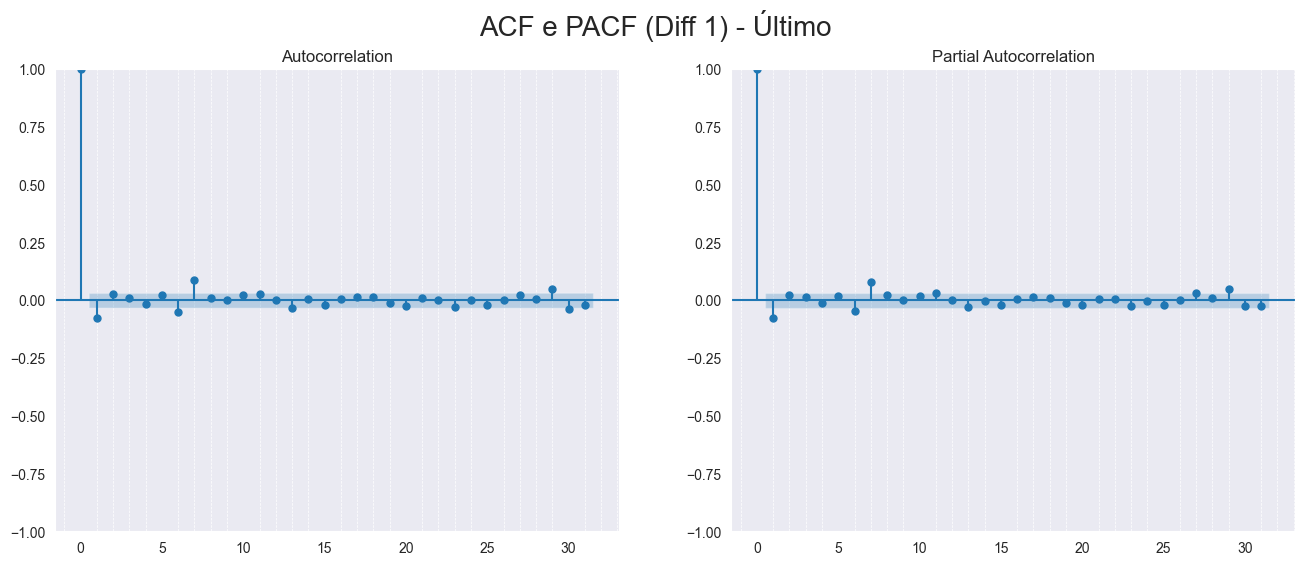

In [378]:
lags = 31

fig, axs = plt.subplots(
    nrows = 1,
    ncols = 2,
    figsize = (16, 6)
)

fig.suptitle(
    f'ACF e PACF (Diff 1) - {col_dict[studied]}',
    fontsize = 20
)

ax = axs[0]
plot_acf(
    df[studied].diff().iloc[1:],
    ax = ax,
    lags = lags
)
ax.xaxis.set_minor_locator(ticker.MultipleLocator(1,1))
ax.set_axisbelow(True)
ax.grid(
    which = 'major'
)
ax.grid(
    which = 'minor',
    linestyle = '--',
    linewidth = 0.5
)

ax = axs[1]
plot_pacf(
    df[studied].diff().iloc[1:],
    ax = ax,
    lags = lags
)
ax.xaxis.set_minor_locator(ticker.MultipleLocator(1,1))
ax.set_axisbelow(True)
ax.grid(
    which = 'major'
)
ax.grid(
    which = 'minor',
    linestyle = '--',
    linewidth = 0.5
)

plt.show()


In [379]:
results = seasonality_search(df, studied, mask)
results [:10]

[(5, np.float64(0.00048782312924364966)),
 (4, np.float64(0.0006936475409834496)),
 (2, np.float64(0.0022367886178864278)),
 (9, np.float64(0.002942650627843461)),
 (3, np.float64(0.0029823848238410638)),
 (16, np.float64(0.0039818638392868115)),
 (6, np.float64(0.005313338414641539)),
 (14, np.float64(0.005573416866753862)),
 (7, np.float64(0.006171634368039723)),
 (8, np.float64(0.006917447916665701))]

0.521502791484965 0.002622169994078906


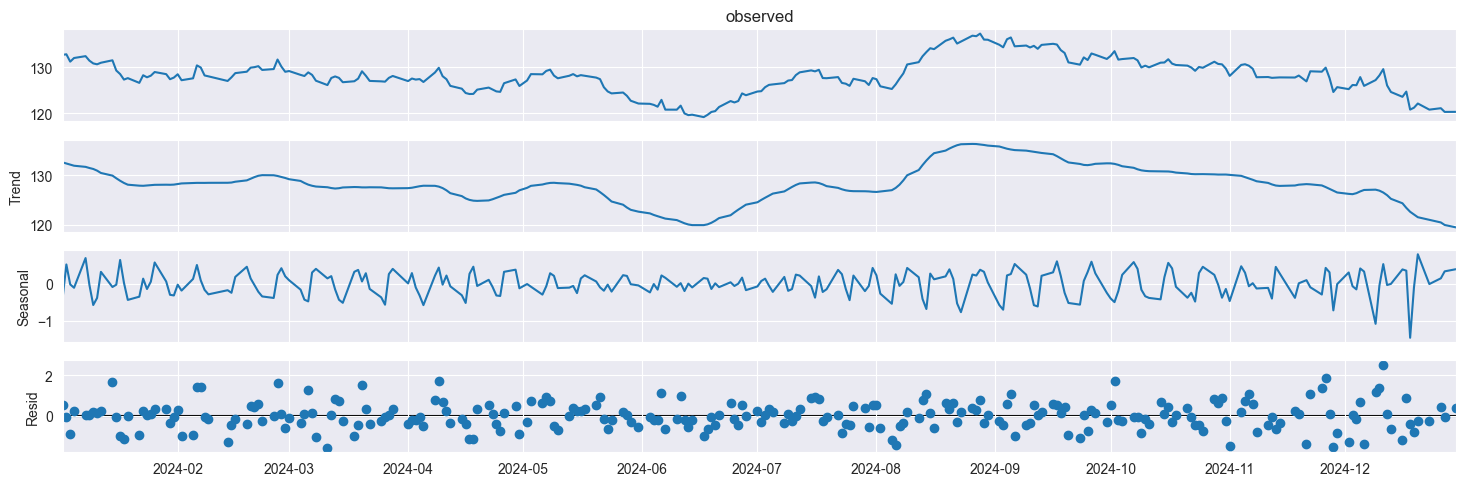

In [380]:
year = 2024
mask = ((df.index > f'{year-1}-12-31') & (df.index < f'{year+1}-01-01'))

mstl = MSTL(
    df[studied].loc[mask],
    periods = [7])
mstl_fit = mstl.fit()

fig = mstl_fit.plot()

fig.set_size_inches(16, 5)

print(mstl_fit.resid.abs().mean(), mstl_fit.resid.mean())

In [381]:
# Retirando colunas ultimo
df = df.drop(['ultimo'], axis=1)
df.head()

,var,alta
data,,
2010-01-29,-0.28,False
2010-02-01,1.79,True
2010-02-02,0.89,True
2010-02-03,-0.08,False
2010-02-04,-4.73,False


***
# 2. Modelo Baseline

### functions

In [382]:
models = {}

In [383]:
from sklearn.metrics import mean_squared_error, accuracy_score, precision_score, recall_score, roc_auc_score

def add_metrics_categorical(
        model_name : str,
        y_pred,
        y_true,
        y_prob = None
):
    models[model_name]['metrics'] = {}
    models[model_name]['metrics']['accuracy'] = accuracy_score(y_true, y_pred)
    models[model_name]['metrics']['precision'] = precision_score(y_true, y_pred)
    models[model_name]['metrics']['recall'] = recall_score(y_true, y_pred)
    if y_prob != None:
        models[model_name]['metrics']['roc_auc'] = roc_auc_score(y_true, y_prob)

In [ ]:
def print_metrics_categorical(
        y_pred,
        y_true,
        y_prob = None
):
    print(f'ACCURACY\t{accuracy_score(y_true = y_true, y_pred = y_pred):4f}\tPRECISION\t{precision_score(y_true = y_true, y_pred = y_pred):4f}\tRECALL\t{recall_score(y_true = y_true, y_pred = y_pred):4f}')
    
    if y_prob != None:
        print(f'ROC AUC\t{roc_auc_score(y_true, y_prob)}')

In [385]:
# Chance de ter alta no final do dia

pred_prob = df[target].value_counts() / df[target].value_counts().sum()
pred_prob = pred_prob[True]
pred_prob

np.float64(0.5116461659251504)

In [386]:
# Quantos dias vamos prever

n_predictions = 30

In [387]:
y = df['alta']

# Ultimos 30 dias reais
y_true = y.iloc[-30:]
y_true

data
2025-05-19     True
2025-05-20     True
2025-05-21    False
2025-05-22    False
2025-05-23     True
2025-05-26     True
2025-05-27     True
2025-05-28    False
2025-05-29    False
2025-05-30    False
2025-06-02    False
2025-06-03     True
2025-06-04    False
2025-06-05    False
2025-06-06    False
2025-06-09    False
2025-06-10     True
2025-06-11     True
2025-06-12     True
2025-06-13    False
2025-06-16     True
2025-06-17    False
2025-06-18    False
2025-06-20    False
2025-06-23    False
2025-06-24     True
2025-06-25    False
2025-06-26     True
2025-06-27    False
2025-06-30     True
Name: alta, dtype: bool

## Baseline

In [388]:
from sklearn.model_selection import KFold, TimeSeriesSplit

SEED = 152
np.random.seed(SEED)

kf_params = {
    'splits': 10,
    'shuffle': True,
    'random_state': SEED
}

kf = KFold(
    n_splits = kf_params['splits'],
    shuffle = kf_params['shuffle'],
    random_state = kf_params['random_state']
)

kft = TimeSeriesSplit(
    n_splits = kf_params['splits']
)

In [389]:
y_pred = []

for i in range(0, n_predictions):
    roll = np.random.random()
    
    if roll < pred_prob:
        y_pred += [True]
    else:
        y_pred += [False]

models['baseline'] = {
    'params': {}
}

add_metrics_categorical(
    'baseline',
    y_pred,
    y_true
)

models['baseline']['metrics']

{'accuracy': 0.4,
 'precision': 0.3684210526315789,
 'recall': 0.5384615384615384}

***
# 3. Modelos Classificadores

## Shifts numéricos

In [390]:
df_class1 = df.copy().reset_index()

shift = [x for x in range(1, 30 + 1)]

for i in shift:
    new_col = f'shift_{i}'

    df_class1[new_col] = df_class1['var'].shift(i)

## Shifts booleanos

In [391]:
shift = [x for x in range(1, 30 + 1)]

for i in shift:
    new_col = f'shift_bool_{i}'

    df_class1[new_col] = df_class1['alta'].shift(i)


## Médias móveis

In [392]:
ma = [x for x in range(1, 15 + 1)]

for i in ma:
    new_col = f'ma_{i}'

    df_class1[new_col] = df_class1['var'].shift(1).rolling(i).mean()

## std

In [393]:
ma = [x for x in range(1, 7+1)]

for i in ma:
    new_col = f'std_{i}'

    df_class1[new_col] = df_class1['var'].shift(1).rolling(i).std()

## Diferenças

## Modelos

In [394]:
df_class1 = df_class1.drop('var',axis=1)

In [395]:
# params = ['shift_1', 'shift_2', 'shift_3', 'shift_4', 'shift_5', 'shift_6', 'shift_7', 'ma_7', 'std_7'] Saved
params = ['ma_2', 'ma_3', 'ma_7', 'std_7']
df_class1 = df_class1.loc[30:]
df_class1[['alta'] + params]

,alta,ma_2,ma_3,ma_7,std_7
30,True,-0.620,-0.456667,0.257143,0.940261
31,False,0.435,0.030000,0.230000,0.899593
32,False,0.510,0.186667,0.241429,0.890869
33,False,-0.175,0.326667,0.027143,0.711189
34,True,-0.645,-0.533333,-0.234286,0.804339
...,...,...,...,...,...
3816,True,-0.780,-0.550000,-0.057143,0.837749
3817,False,0.020,-0.370000,-0.062857,0.833521
3818,True,-0.285,-0.326667,-0.147143,0.903709
3819,False,-0.015,0.140000,-0.218571,0.761280


In [396]:
y = df_class1['alta']
x = df_class1[params]

In [397]:
df.tail()

,var,alta
data,,
2025-06-24,0.45,True
2025-06-25,-1.02,False
2025-06-26,0.99,True
2025-06-27,-0.18,False
2025-06-30,1.45,True


In [398]:
from sklearn.model_selection import train_test_split

# x_train, x_test, y_train, y_test = train_test_split(
#     x,
#     y,
#     test_size = 0.25,
#     random_state = SEED,
#     stratify = y
# )

x_train = x[:-n_predictions]
y_train = y[:-n_predictions]

x_test = x[-n_predictions:]
y_test = y[-n_predictions:]


### Logistic Regression

#### Choosing parameters

In [399]:
from sklearn.linear_model import LogisticRegression

current_model = 'kneighborsclassifier1'
models[current_model] = {}

acc = {}

for solver in ['lbfgs','sag','saga','newton-cg','liblinear']:
    model = LogisticRegression(
        random_state = SEED,
        solver = solver
    )

    model.fit(x_train, y_train)
    model.fit(x_train, y_train)
    
    y_pred = model.predict(x_test)
    test_score = accuracy_score(y_test, y_pred)

    y_pred = model.predict(x_train)
    train_score = accuracy_score(y_train, y_pred)

    acc[solver] = (test_score, train_score)
acc

{'lbfgs': (0.43333333333333335, 0.49933528316936987),
 'sag': (0.43333333333333335, 0.4990693964371178),
 'saga': (0.43333333333333335, 0.4990693964371178),
 'newton-cg': (0.43333333333333335, 0.4990693964371178),
 'liblinear': (0.43333333333333335, 0.4990693964371178)}

#### Choosing X

#### Cross Validation


In [400]:
def validate_logistic_regression(
        x,
        y,
        solver,
        random_state = SEED
):
    fold = 1
    for train_idx, test_idx in kft.split(x, y):
        model = LogisticRegression(
            solver = solver,
            random_state = random_state
        )

        x_train = x.iloc[train_idx]
        y_train = y.iloc[train_idx]

        x_test = x.iloc[test_idx]
        y_test = y.iloc[test_idx]

        model.fit(x_train, y_train)

        y_pred = model.predict(x_test)
        
        print(f'============= FOLD {fold} =============')
        print(f'Train {len(y_train)} | Test {len(y_test)}')

        print_metrics_categorical(
            y_pred = y_pred,
            y_true = y_test)

        fold +=1

In [401]:
validate_logistic_regression(
    x,
    y,
    solver = 'lbfgs'
)

============= FOLD 1 =============
Train 351 | Test 344
ACCURACY	0.444767	PRECISION	0.433333	RECALL	0.467066
============= FOLD 2 =============
Train 695 | Test 344
ACCURACY	0.491279	PRECISION	0.473118	RECALL	0.533333
============= FOLD 3 =============
Train 1039 | Test 344
ACCURACY	0.523256	PRECISION	0.490566	RECALL	0.484472
============= FOLD 4 =============
Train 1383 | Test 344
ACCURACY	0.462209	PRECISION	0.511905	RECALL	0.229947
============= FOLD 5 =============
Train 1727 | Test 344
ACCURACY	0.485465	PRECISION	0.537190	RECALL	0.349462
============= FOLD 6 =============
Train 2071 | Test 344
ACCURACY	0.502907	PRECISION	0.533654	RECALL	0.600000
============= FOLD 7 =============
Train 2415 | Test 344
ACCURACY	0.531977	PRECISION	0.540773	RECALL	0.700000
============= FOLD 8 =============
Train 2759 | Test 344
ACCURACY	0.505814	PRECISION	0.518657	RECALL	0.772222
============= FOLD 9 =============
Train 3103 | Test 344
ACCURACY	0.456395	PRECISION	0.470383	RECALL	0.794118
============

### KNN

In [402]:
from sklearn.neighbors import KNeighborsClassifier

current_model = 'kneighborsclassifier1'
models[current_model] = {}

acc = {}

min_n = 3
max_n = 20

for n in range(min_n, max_n+1):  
    model = KNeighborsClassifier(
        n_neighbors = n
    )

    model.fit(x_train, y_train)
    
    y_pred = model.predict(x_test)
    test_score = accuracy_score(y_test, y_pred)

    y_pred = model.predict(x_train)
    train_score = accuracy_score(y_train, y_pred)

    acc[n] = (test_score, train_score)
acc

{3: (0.43333333333333335, 0.7612337144376495),
 4: (0.4666666666666667, 0.6889125232650891),
 5: (0.5, 0.6955596915713906),
 6: (0.4666666666666667, 0.6593990959851104),
 7: (0.4666666666666667, 0.6554107950013295),
 8: (0.4, 0.6346716298856687),
 9: (0.43333333333333335, 0.640521137995214),
 10: (0.4666666666666667, 0.6277585748471152),
 11: (0.43333333333333335, 0.6285562350438713),
 12: (0.4666666666666667, 0.6195160861473012),
 13: (0.4, 0.6165913320925286),
 14: (0.43333333333333335, 0.6179207657537888),
 15: (0.4666666666666667, 0.6112735974474873),
 16: (0.43333333333333335, 0.6086147301249668),
 17: (0.43333333333333335, 0.6027652220154214),
 18: (0.36666666666666664, 0.6003722414251529),
 19: (0.3, 0.6011699016219091),
 20: (0.3333333333333333, 0.6024993352831693)}

### RandomForestClassifier 

In [403]:
from sklearn.ensemble import RandomForestClassifier
current_model = 'randomforestclassifier1'
models[current_model] = {}

acc = {}

min_depth = 2
max_depth = 20

for depth in range(min_depth, max_depth+1):
    model = RandomForestClassifier(
        n_estimators = 100,
        max_depth = depth,
        random_state = SEED
    )

    model.fit(x_train, y_train)
    
    y_pred = model.predict(x_test)
    test_score = accuracy_score(y_test, y_pred)

    y_pred = model.predict(x_train)
    train_score = accuracy_score(y_train, y_pred)

    acc[depth] = (test_score, train_score)
acc

{2: (0.5333333333333333, 0.5533102898165382),
 3: (0.5333333333333333, 0.5801648497739963),
 4: (0.5333333333333333, 0.604892315873438),
 5: (0.5666666666666667, 0.6429141185854825),
 6: (0.5666666666666667, 0.6851901090135603),
 7: (0.5, 0.7264025525126296),
 8: (0.5, 0.7753257112470088),
 9: (0.5666666666666667, 0.8237170965168839),
 10: (0.5333333333333333, 0.863865993086945),
 11: (0.5, 0.9077373039085349),
 12: (0.5333333333333333, 0.9436320127625631),
 13: (0.4666666666666667, 0.9657006115394842),
 14: (0.4, 0.978463174687583),
 15: (0.5, 0.9883009837809094),
 16: (0.43333333333333335, 0.9954799255517149),
 17: (0.5666666666666667, 0.9981387928742356),
 18: (0.5, 0.9973411326774794),
 19: (0.4666666666666667, 0.999734113267748),
 20: (0.43333333333333335, 0.999734113267748)}

#### Cross-Validation

In [404]:
def validate_randomforest(
        x,
        y,
        n_estimators,
        max_depth,
        random_state = SEED
):
    for train_idx, test_idx in kf.split(x ,y):
        model = RandomForestClassifier(
            n_estimators = n_estimators,
            max_depth = max_depth,
            random_state = random_state
        )

        x_train = x.iloc[train_idx]
        y_train = y.iloc[train_idx]

        x_test = x.iloc[test_idx]
        y_test = y.iloc[test_idx]

        model.fit(x_train, y_train)

        y_pred = model.predict(x_test)
        
        print(f'============= FOLD {fold} =============')
        print(f'Train {len(y_train)} | Test {len(y_test)}')

        print_metrics_categorical(y_test, y_pred)

        fold +=1

In [405]:
current_model = 'randomforestclassifier1'
models[current_model] = {}
models[current_model]['params'] = {
    'n_estimators':100,
    'max_depth':10
}

fold = 1
for train_idx, test_idx in kft.split(x ,y):
    model = RandomForestClassifier(
        n_estimators = models[current_model]['params']['n_estimators'],
        max_depth = models[current_model]['params']['max_depth'],
        random_state = SEED
    )

    x_train = x.iloc[train_idx]
    y_train = y.iloc[train_idx]

    x_test = x.iloc[test_idx]
    y_test = y.iloc[test_idx]

    model.fit(x_train, y_train)

    y_pred = model.predict(x_test)
    
    print(f'============= FOLD {fold} =============')
    print(f'Train {len(y_train)} | Test {len(y_test)}')

    print_metrics_categorical(
        y_pred = y_pred,
        y_true = y_test
        )

    fold +=1

============= FOLD 1 =============
Train 351 | Test 344
ACCURACY	0.482558	PRECISION	0.466258	RECALL	0.455090
============= FOLD 2 =============
Train 695 | Test 344
ACCURACY	0.476744	PRECISION	0.456647	RECALL	0.478788
============= FOLD 3 =============
Train 1039 | Test 344
ACCURACY	0.514535	PRECISION	0.480769	RECALL	0.465839
============= FOLD 4 =============
Train 1383 | Test 344
ACCURACY	0.508721	PRECISION	0.567164	RECALL	0.406417
============= FOLD 5 =============
Train 1727 | Test 344
ACCURACY	0.476744	PRECISION	0.521739	RECALL	0.387097
============= FOLD 6 =============
Train 2071 | Test 344
ACCURACY	0.514535	PRECISION	0.560000	RECALL	0.454054
============= FOLD 7 =============
Train 2415 | Test 344
ACCURACY	0.505814	PRECISION	0.528409	RECALL	0.516667
============= FOLD 8 =============
Train 2759 | Test 344
ACCURACY	0.531977	PRECISION	0.551913	RECALL	0.561111
============= FOLD 9 =============
Train 3103 | Test 344
ACCURACY	0.546512	PRECISION	0.537234	RECALL	0.594118
============

***
# 4. Modelos Time Series

## Modificando DataFrame

In [406]:
df_ts = df[['var']].copy().reset_index()
df_ts = df_ts.rename({
    'data':'ds',
    'var':'y'
},axis=1)
df_ts

,ds,y
0,2010-01-29,-0.28
1,2010-02-01,1.79
2,2010-02-02,0.89
3,2010-02-03,-0.08
4,2010-02-04,-4.73
...,...,...
3816,2025-06-24,0.45
3817,2025-06-25,-1.02
3818,2025-06-26,0.99
3819,2025-06-27,-0.18


In [407]:
mask = (df_ts['ds'] < '2020-01-01') | (df_ts['ds'] > '2020-12-31')
df_ts_no2020 = df_ts[mask]
df_ts_no2020

,ds,y
0,2010-01-29,-0.28
1,2010-02-01,1.79
2,2010-02-02,0.89
3,2010-02-03,-0.08
4,2010-02-04,-4.73
...,...,...
3816,2025-06-24,0.45
3817,2025-06-25,-1.02
3818,2025-06-26,0.99
3819,2025-06-27,-0.18


In [408]:
df_ts_filled = df_ts.copy()
df_ts_filled = df_ts_filled.set_index(df_ts_filled['ds'])
df_ts_filled = df_ts_filled.drop('ds', axis=1)
df_ts_filled = df_ts_filled.asfreq('d')
df_ts_filled = df_ts_filled.reset_index()
df_ts_filled

,ds,y
0,2010-01-29,-0.28
1,2010-01-30,NaN
2,2010-01-31,NaN
3,2010-02-01,1.79
4,2010-02-02,0.89
...,...,...
5627,2025-06-26,0.99
5628,2025-06-27,-0.18
5629,2025-06-28,NaN
5630,2025-06-29,NaN


In [409]:
filled_days = df_ts_filled['y'].isna().copy()

In [410]:
df_ts_filled = df_ts_filled.fillna('0')

In [411]:
df_ts_filled['y'] = df_ts_filled['y'].astype(float)

## Train-Test

In [412]:
n_predictions = 30

In [413]:
df_ts_train = df_ts_no2020[: - n_predictions]
df_ts_test = df_ts_no2020[-n_predictions:]

make_alta(df_ts_train, 'y')
make_alta(df_ts_test, 'y')

display(df_ts_train.tail())
display(df_ts_test.head())

D:\Temp\ipykernel_11608\3727618979.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

D:\Temp\ipykernel_11608\3727618979.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,ds,y,alta
3786,2025-05-12,0.04,True
3787,2025-05-13,1.76,True
3788,2025-05-14,-0.39,False
3789,2025-05-15,0.66,True
3790,2025-05-16,-0.11,False


,ds,y,alta
3791,2025-05-19,0.32,True
3792,2025-05-20,0.34,True
3793,2025-05-21,-1.59,False
3794,2025-05-22,-0.44,False
3795,2025-05-23,0.40,True


In [414]:
df_ts_filled_train = df_ts_filled[: - n_predictions]
df_ts_filled_test = df_ts_filled[-n_predictions:]

make_alta(df_ts_filled_train, 'y')
make_alta(df_ts_filled_test, 'y')


display(df_ts_filled_train.tail())
display(df_ts_filled_test.head())

D:\Temp\ipykernel_11608\3727618979.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

D:\Temp\ipykernel_11608\3727618979.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,ds,y,alta
5597,2025-05-27,1.02,True
5598,2025-05-28,-0.47,False
5599,2025-05-29,-0.25,False
5600,2025-05-30,-1.09,False
5601,2025-05-31,0.00,False


,ds,y,alta
5602,2025-06-01,0.00,False
5603,2025-06-02,-0.18,False
5604,2025-06-03,0.56,True
5605,2025-06-04,-0.40,False
5606,2025-06-05,-0.56,False


## Prophet

### import

In [415]:
from prophet import Prophet
from prophet.plot import plot_plotly

In [416]:
model = Prophet()
model.fit(df_ts_filled_train)

12:22:14 - cmdstanpy - INFO - Chain [1] start processing
12:22:15 - cmdstanpy - INFO - Chain [1] done processing


In [417]:
future = model.make_future_dataframe(periods = n_predictions)
future.tail()

,ds
5627,2025-06-26
5628,2025-06-27
5629,2025-06-28
5630,2025-06-29
5631,2025-06-30


In [418]:
forecast = model.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
5627,2025-06-26,-0.008004,-1.463363,1.571543
5628,2025-06-27,-0.044618,-1.617660,1.476843
5629,2025-06-28,-0.016050,-1.551167,1.613855
5630,2025-06-29,-0.005767,-1.583167,1.629740
5631,2025-06-30,-0.024040,-1.492160,1.526939


In [419]:
plot_plotly(model, forecast)

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'marker': {'color': 'black', 'size': 4},
              'mode': 'markers',
              'name': 'Actual',
              'type': 'scatter',
              'x': array(['2010-01-29T00:00:00.000000000', '2010-01-30T00:00:00.000000000',
                          '2010-01-31T00:00:00.000000000', ..., '2025-05-29T00:00:00.000000000',
                          '2025-05-30T00:00:00.000000000', '2025-05-31T00:00:00.000000000'],
                         shape=(5602,), dtype='datetime64[ns]'),
              'y': {'bdata': ('7FG4HoXr0b8AAAAAAAAAAAAAAAAAAA' ... 'AAAADQv3E9CtejcPG/AAAAAAAAAAA='),
                    'dtype': 'f8'}},
             {'hoverinfo': 'skip',
              'line': {'width': 0},
              'mode': 'lines',
              'type': 'scatter',
              'x': array(['2010-01-29T00:00:00.000000000', '2010-01-30T00:00:00.000000000',
                          '2010-01-31T00:00:00.000000000', ..., '2025-06-28T00:00:00.000000000',
                          '2025-06-29T00:00:00.000000000', '2025-06-30T00:00:00.000000000'],
                         shape=(5632,), dtype='datetime64[ns]'),
              'y': {'bdata': ('x9Oha+0s+b8iCv1ECoX5vxu23OpEPv' ... 'IflNH4vzYjMYemVPm/fvNeeuPf978='),
                    'dtype': 'f8'}},
             {'fill': 'tonexty',
              'fillcolor': 'rgba(0, 114, 178, 0.2)',
              'line': {'color': '#0072B2', 'width': 2},
              'mode': 'lines',
              'name': 'Predicted',
              'type': 'scatter',
              'x': array(['2010-01-29T00:00:00.000000000', '2010-01-30T00:00:00.000000000',
                          '2010-01-31T00:00:00.000000000', ..., '2025-06-28T00:00:00.000000000',
                          '2025-06-29T00:00:00.000000000', '2025-06-30T00:00:00.000000000'],
                         shape=(5632,), dtype='datetime64[ns]'),
              'y': {'bdata': ('tY5jU2qmsr/GmmDDibinv8UibLSGza' ... 'feW2+Qv9xUwBiIn3e/QWx+W9idmL8='),
                    'dtype': 'f8'}},
             {'fill': 'tonexty',
              'fillcolor': 'rgba(0, 114, 178, 0.2)',
              'hoverinfo': 'skip',
              'line': {'width': 0},
              'mode': 'lines',
              'type': 'scatter',
              'x': array(['2010-01-29T00:00:00.000000000', '2010-01-30T00:00:00.000000000',
                          '2010-01-31T00:00:00.000000000', ..., '2025-06-28T00:00:00.000000000',
                          '2025-06-29T00:00:00.000000000', '2025-06-30T00:00:00.000000000'],
                         shape=(5632,), dtype='datetime64[ns]'),
              'y': {'bdata': ('AOuvg9a5+T9g4p/errb3P73A/h/ALv' ... 'GJWdL5P/3UZJlqE/o/Rp9ksldu+D8='),
                    'dtype': 'f8'}}],
    'layout': {'height': 600,
               'showlegend': False,
               'template': '...',
               'width': 900,
               'xaxis': {'rangeselector': {'buttons': [{'count': 7, 'label': '1w', 'step': 'day', 'stepmode': 'backward'},
                                                       {'count': 1,
                                                        'label': '1m',
                                                        'step': 'month',
                                                        'stepmode': 'backward'},
                                                       {'count': 6,
                                                        'label': '6m',
                                                        'step': 'month',
                                                        'stepmode': 'backward'},
                                                       {'count': 1, 'label': '1y', 'step': 'year', 'stepmode': 'backward'},
                                                       {'step': 'all'}]},
                         'rangeslider': {'visible': True},
                         'title': {'text': 'ds'},
                         'type': 'date'},
               'yaxis': {'title': {'text': 'y'}}}
})

In [420]:
df_pred = make_alta(forecast[-n_predictions:], from_column='yhat')[['ds', 'alta']]
df_pred.head(3)

D:\Temp\ipykernel_11608\3727618979.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,ds,alta
5602,2025-06-01,False
5603,2025-06-02,False
5604,2025-06-03,True


In [421]:
df_check = pd.merge(
    df_pred,
    df_ts_filled_test,
    on = 'ds',
    suffixes = ['_pred', '_test']
)
print_metrics_categorical(
    y_pred = df_check['alta_pred'], 
    y_true = df_check['alta_test'])



ACCURACY	0.700000	PRECISION	0.444444	RECALL	0.500000


In [ ]:
def validate_prophet():

    model = Prophet()
    future = model.make_future_dataframe(periods = n_predictions)
    forecast = model.predict(future)
    df_pred = make_alta(forecast[-n_predictions:], from_column='yhat')[['ds', 'alta']]
    df_check = pd.merge(
        df_pred,
        df_ts_filled_test,
        on = 'ds',
        suffixes = ['_pred', '_test']
    )


In [ ]:
def validate_prophet(
        df,
        column = 'alta'
):
    fold = 1
    for train_idx, test_idx in kft.split(df, df):
        model = Prophet(
        )
        df_train = df.iloc[train_idx]
        df_test = df.iloc[test_idx]

        model.fit(df_train)
        
        future = model.make_future_dataframe(periods = n_predictions)
        
        
        forecast = model.predict(future)
        
        df_pred = make_alta(forecast, from_column='yhat')[['ds', 'alta']]
        df_true = make_alta(df_test, from_column='y')[['ds', 'alta']]


        print(f'============= FOLD {fold} =============')
        print(f'Train {len(df_train)} | Test {len(df_test)}')

        print(df_test[column])
        print_metrics_categorical(
            y_pred = df_pred[column],
            y_true = df_true[column])

        fold +=1

In [434]:
for train_idx, test_idx in kft.split(df_ts_filled, df_ts_filled):
    print(len(train_idx), len(test_idx))

512 512
1024 512
1536 512
2048 512
2560 512
3072 512
3584 512
4096 512
4608 512
5120 512


In [438]:
validate_prophet(df_ts_filled)


Exception: Model has not been fit.

# END